# Phase 4 - Evaluation et explicabilite (CICIDS2017)

Ce notebook EVALUE et COMPARE les trois approches de detection sur le jeu de
TEST complet : la baseline de regles statiques, l'Isolation Forest, et le
MODELE GAGNANT du bake-off de la Phase 3 (`best_model.pkl`, un pipeline
StandardScaler + modele qui consomme des features BRUTES). Il affiche le
classement du bake-off (F1 par validation croisee), les matrices de confusion,
un tableau de metriques comparatif, la reduction des faux positifs face a la
baseline de regles, l'importance globale des features du gagnant, et
l'explicabilite "pourquoi cette alerte" pour quelques flux d'attaque detectes.
Tous les chiffres sont sauvegardes dans reports/metrics.json.

## 1. Imports et chargement des artefacts (Phase 3)

On charge le jeu de test (features BRUTES + labels), la liste des features, le
modele gagnant du bake-off + ses metadonnees, le tableau de resultats de la
validation croisee, l'Isolation Forest et le scaler gele (pour la baseline
iso), les moyennes BENIGN (pour l'explicabilite) et les regles statiques.

In [1]:
# 1. Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance
import joblib

sns.set(style="whitegrid")

# Chemin absolu de la racine du projet
BASE = "/home/samouraifox/Work/stuff/S6/Notes_Ai/projet-final/model-building/Detection-explicable-danomalies"

# Chargement du jeu de test complet (features BRUTES + labels)
df = pd.read_parquet(BASE + "/data/processed/test_set.parquet")
print(f"Shape du jeu de test : {df.shape}")
print(df["Label_binary"].value_counts())

# Chargement de la liste ordonnee des features et des artefacts du contrat
features = joblib.load(BASE + "/models/features.pkl")
best_model = joblib.load(BASE + "/models/best_model.pkl")   # pipeline gagnant (entree BRUTE)
iso = joblib.load(BASE + "/models/isolation_forest.pkl")    # baseline non supervisee
scaler = joblib.load(BASE + "/models/scaler.pkl")           # scaler gele (sert a l'iso)
benign_means = joblib.load(BASE + "/models/benign_means.pkl")  # moyennes BENIGN (explicabilite)

# Metadonnees du gagnant + tableau de la validation croisee du bake-off
with open(BASE + "/models/best_model_meta.json") as fichier:
    best_model_meta = json.load(fichier)
with open(BASE + "/models/cv_results.json") as fichier:
    cv_results = json.load(fichier)
with open(BASE + "/models/rule_baseline.json") as fichier:
    rule_baseline = json.load(fichier)

# Nom du modele gagnant (sert de libelle dans tout le notebook)
nom_gagnant = best_model_meta["name"]
print(f"Nombre de features : {len(features)}")
print(f"Modele gagnant du bake-off : {nom_gagnant}")
print(f"F1 CV du gagnant : {best_model_meta['cv_f1_mean']:.4f} +/- {best_model_meta['cv_f1_std']:.4f}")
print(f"Logique des regles : {rule_baseline['logique']}")

Shape du jeu de test : (756240, 73)
Label_binary
0    628518
1    127722
Name: count, dtype: int64
Nombre de features : 70
Modele gagnant du bake-off : XGBoost
F1 CV du gagnant : 0.9964 +/- 0.0005
Logique des regles : OR


## 2. Predictions des trois approches sur le TEST

Convention du contrat : le GAGNANT consomme des features BRUTES
(`best_model.predict(df[features])`, son scaler interne re-met a l'echelle).
L'Isolation Forest predit sur les features mises a l'echelle par le scaler gele
(`scaler.transform`). Les regles statiques s'appliquent sur les features
BRUTES. La verite terrain est `Label_binary` (0 = BENIGN, 1 = attaque).

In [2]:
# 2a. Matrices de features et verite terrain
X = df[features]                 # features BRUTES (gagnant + regles + explicabilite)
Xs = scaler.transform(X)         # features mises a l'echelle (pour l'Isolation Forest)
y_true = df["Label_binary"]      # verite terrain : 0 = BENIGN, 1 = attaque

# 2b. Modele gagnant : prediction binaire + score de risque (proba d'attaque) sur features BRUTES
y_pred_best = best_model.predict(X)
proba_best = best_model.predict_proba(X)[:, 1]   # score de risque = proba de la classe attaque

# 2c. Isolation Forest : -1 = anomalie -> 1 (attaque), 1 = normal -> 0 (BENIGN)
iso_pred_raw = iso.predict(Xs)
y_pred_iso = np.where(iso_pred_raw == -1, 1, 0)  # -1 anomalie -> attaque (1), 1 normal -> BENIGN (0)

# 2d. Baseline de regles statiques sur les features BRUTES (OR logique des 5 regles)
seuil_avg_packet_size = 496.0
seuil_bwd_packets_s = 58823.0
seuil_flow_packets_s = 500000.0
seuil_fwd_packets_court = 3
seuil_flow_duration_long = 1000000.0
seuil_flow_bytes_s = 12000000.0

regle_avg_size = X["Average Packet Size"] > seuil_avg_packet_size
regle_bwd_rate = X["Bwd Packets/s"] > seuil_bwd_packets_s
regle_flow_rate = X["Flow Packets/s"] > seuil_flow_packets_s
regle_court_long = (X["Total Fwd Packets"] <= seuil_fwd_packets_court) & (X["Flow Duration"] > seuil_flow_duration_long)
regle_bytes_rate = X["Flow Bytes/s"] > seuil_flow_bytes_s

# OR logique des 5 regles -> prediction de la baseline
y_pred_rule = (regle_avg_size | regle_bwd_rate | regle_flow_rate | regle_court_long | regle_bytes_rate).astype(int)

print("Predictions calculees pour les 3 approches.")
print(f"Positifs (attaque) - Regles           : {int(y_pred_rule.sum())}")
print(f"Positifs (attaque) - Isolation Forest : {int(y_pred_iso.sum())}")
print(f"Positifs (attaque) - {nom_gagnant:18s} : {int(y_pred_best.sum())}")

Predictions calculees pour les 3 approches.
Positifs (attaque) - Regles           : 176103
Positifs (attaque) - Isolation Forest : 82287
Positifs (attaque) - XGBoost            : 127997


## 3. Bake-off : classement des 7 modeles par validation croisee

On represente le F1 moyen (validation croisee 10-fold sur le sous-echantillon
du train) +/- ecart-type des 7 modeles compares en Phase 3, lus dans
`cv_results.json`. Le modele gagnant est mis en evidence en couleur. C'est la
justification du choix du modele principal.

=== Bake-off : F1 par validation croisee (10-fold) ===
            Modele  F1_moyen  F1_std  selected
        GaussianNB    0.3770  0.0160     False
         LinearSVC    0.8525  0.0040     False
      DecisionTree    0.8567  0.0041     False
LogisticRegression    0.8597  0.0051     False
               KNN    0.9695  0.0066     False
      RandomForest    0.9947  0.0008     False
           XGBoost    0.9964  0.0005      True


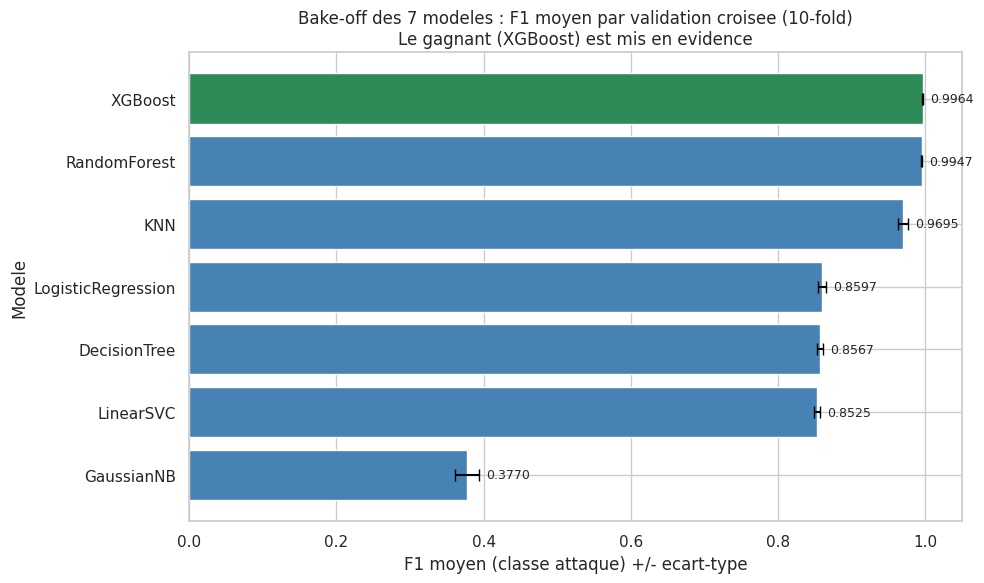

In [3]:
# 3. Bar chart du bake-off : F1 CV moyen +/- std des 7 modeles (gagnant en evidence)
# Lecture du tableau de validation croisee + tri par F1 moyen croissant (lisible)
noms_modeles = []
f1_moyens = []
f1_stds = []
selected_flags = []
for nom, res in cv_results.items():
    noms_modeles.append(nom)
    f1_moyens.append(res["cv_f1_mean"])
    f1_stds.append(res["cv_f1_std"])
    selected_flags.append(res["selected"])

df_bakeoff = pd.DataFrame({
    "Modele": noms_modeles,
    "F1_moyen": f1_moyens,
    "F1_std": f1_stds,
    "selected": selected_flags,
}).sort_values("F1_moyen").reset_index(drop=True)

print("=== Bake-off : F1 par validation croisee (10-fold) ===")
print(df_bakeoff.round(4).to_string(index=False))

# Couleurs : gagnant en vert, les autres en gris-bleu
couleurs_bakeoff = ["seagreen" if sel else "steelblue" for sel in df_bakeoff["selected"]]

plt.figure(figsize=(10, 6))
plt.barh(df_bakeoff["Modele"], df_bakeoff["F1_moyen"],
         xerr=df_bakeoff["F1_std"], color=couleurs_bakeoff,
         capsize=4, error_kw={"ecolor": "black"})
plt.title("Bake-off des 7 modeles : F1 moyen par validation croisee (10-fold)\nLe gagnant (" + nom_gagnant + ") est mis en evidence")
plt.xlabel("F1 moyen (classe attaque) +/- ecart-type")
plt.ylabel("Modele")
plt.xlim(0, 1.05)
# Annotation de la valeur du F1 au bout de chaque barre
for i, (val, std) in enumerate(zip(df_bakeoff["F1_moyen"], df_bakeoff["F1_std"])):
    plt.text(val + std + 0.01, i, f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/11_bakeoff_cv_f1.png", dpi=120)
plt.show()

## 4. Matrices de confusion des trois approches

Pour chaque approche on affiche la matrice de confusion (lignes = verite,
colonnes = prediction). Les faux positifs (BENIGN flagges attaque) sont la
cellule en haut a droite : ils representent les alertes inutiles que les
analystes du SOC doivent traiter.

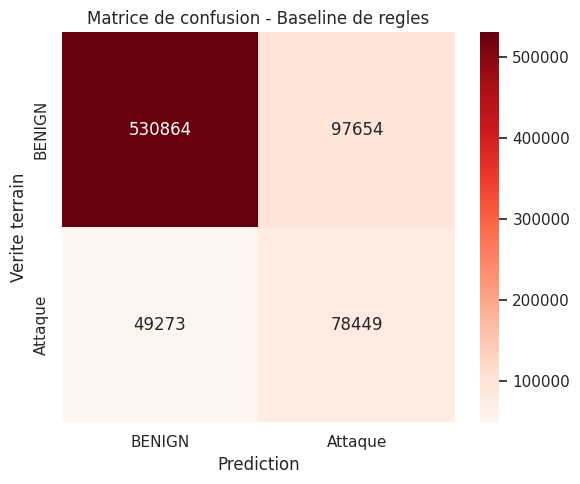

In [4]:
# 4a. Matrice de confusion - Baseline de regles
cm_rule = confusion_matrix(y_true, y_pred_rule)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rule, annot=True, fmt="d", cmap="Reds",
            xticklabels=["BENIGN", "Attaque"], yticklabels=["BENIGN", "Attaque"])
plt.title("Matrice de confusion - Baseline de regles")
plt.xlabel("Prediction")
plt.ylabel("Verite terrain")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/06_cm_regles.png", dpi=120)
plt.show()

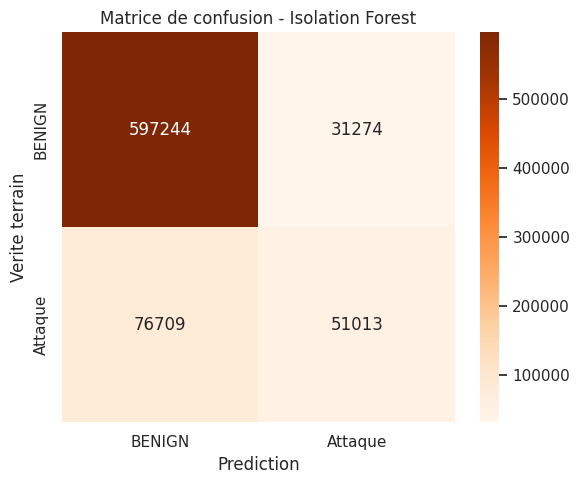

In [5]:
# 4b. Matrice de confusion - Isolation Forest
cm_iso = confusion_matrix(y_true, y_pred_iso)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_iso, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["BENIGN", "Attaque"], yticklabels=["BENIGN", "Attaque"])
plt.title("Matrice de confusion - Isolation Forest")
plt.xlabel("Prediction")
plt.ylabel("Verite terrain")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/07_cm_isolation_forest.png", dpi=120)
plt.show()

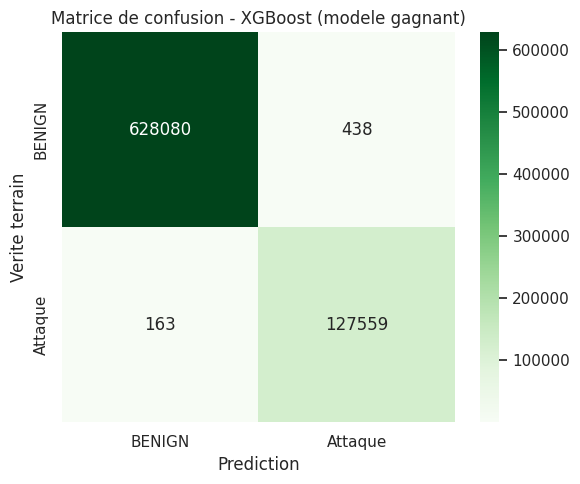

In [6]:
# 4c. Matrice de confusion - Modele gagnant du bake-off
cm_best = confusion_matrix(y_true, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens",
            xticklabels=["BENIGN", "Attaque"], yticklabels=["BENIGN", "Attaque"])
plt.title("Matrice de confusion - " + nom_gagnant + " (modele gagnant)")
plt.xlabel("Prediction")
plt.ylabel("Verite terrain")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/08_cm_best_model.png", dpi=120)
plt.show()

## 5. Tableau comparatif des metriques

On calcule pour les trois approches : precision, recall, f1 (sur la classe
attaque), accuracy globale, nombre de faux positifs et taux de faux positifs
(FP / (FP + TN), c'est-a-dire la proportion de BENIGN flagges a tort). Le
taux de faux positifs est la metrique centrale du projet.

In [7]:
# 5a. Faux positifs (FP) et vrais negatifs (TN) lus dans chaque matrice de confusion
# Cellule [0, 1] = BENIGN (verite 0) predit attaque (1) = faux positif
# Cellule [0, 0] = BENIGN (verite 0) predit BENIGN (0) = vrai negatif
fp_rule = int(cm_rule[0, 1])
tn_rule = int(cm_rule[0, 0])
fp_iso = int(cm_iso[0, 1])
tn_iso = int(cm_iso[0, 0])
fp_best = int(cm_best[0, 1])
tn_best = int(cm_best[0, 0])

# Taux de faux positifs = FP / (FP + TN)
fp_rate_rule = fp_rule / (fp_rule + tn_rule)
fp_rate_iso = fp_iso / (fp_iso + tn_iso)
fp_rate_best = fp_best / (fp_best + tn_best)

# 5b. Construction du tableau comparatif (DataFrame)
modeles = ["Regles", "Isolation Forest", nom_gagnant]
predictions = {"Regles": y_pred_rule, "Isolation Forest": y_pred_iso, nom_gagnant: y_pred_best}
fp_par_modele = {"Regles": fp_rule, "Isolation Forest": fp_iso, nom_gagnant: fp_best}
fp_rate_par_modele = {"Regles": fp_rate_rule, "Isolation Forest": fp_rate_iso, nom_gagnant: fp_rate_best}

# Dictionnaire des metriques par modele + boucle for (motif autorise)
comparaison = {"Modele": [], "Precision": [], "Recall": [], "F1": [],
               "Accuracy": [], "Faux positifs": [], "Taux de FP": []}
for nom in modeles:
    y_pred = predictions[nom]
    comparaison["Modele"].append(nom)
    comparaison["Precision"].append(precision_score(y_true, y_pred, zero_division=0))
    comparaison["Recall"].append(recall_score(y_true, y_pred, zero_division=0))
    comparaison["F1"].append(f1_score(y_true, y_pred, zero_division=0))
    comparaison["Accuracy"].append(accuracy_score(y_true, y_pred))
    comparaison["Faux positifs"].append(fp_par_modele[nom])
    comparaison["Taux de FP"].append(fp_rate_par_modele[nom])

df_comparaison = pd.DataFrame(comparaison)
print("=== Tableau comparatif des metriques (jeu de test) ===")
print(df_comparaison.round(4).to_string(index=False))

=== Tableau comparatif des metriques (jeu de test) ===
          Modele  Precision  Recall     F1  Accuracy  Faux positifs  Taux de FP
          Regles     0.4455  0.6142 0.5164    0.8057          97654      0.1554
Isolation Forest     0.6199  0.3994 0.4858    0.8572          31274      0.0498
         XGBoost     0.9966  0.9987 0.9976    0.9992            438      0.0007


## 6. Reduction des faux positifs face a la baseline de regles

L'objectif metier vise une forte reduction des faux positifs par rapport a la
baseline de regles. On calcule la reduction reelle apportee par le modele
gagnant et par l'Isolation Forest, puis on la situe honnetement par rapport a
la fourchette de reference 60-80 % (on rapporte les vrais chiffres meme s'ils
en sortent).

In [8]:
# 6. Reduction des faux positifs par rapport a la baseline de regles
fp_reduction_best = (fp_rule - fp_best) / fp_rule * 100
fp_reduction_iso = (fp_rule - fp_iso) / fp_rule * 100

print(f"Faux positifs - Baseline de regles : {fp_rule}")
print(f"Faux positifs - Isolation Forest   : {fp_iso}")
print(f"Faux positifs - {nom_gagnant:18s} : {fp_best}")
print(f"\nReduction des FP ({nom_gagnant} vs Regles)    : {fp_reduction_best:.4f} %")
print(f"Reduction des FP (Isolation Forest vs Regles) : {fp_reduction_iso:.4f} %")

# Situation honnete par rapport a la fourchette de reference 60-80 %
cible_min = 60.0
cible_max = 80.0
dans_cible_best = (fp_reduction_best >= cible_min) and (fp_reduction_best <= cible_max)
dans_cible_iso = (fp_reduction_iso >= cible_min) and (fp_reduction_iso <= cible_max)
print(f"\nReference : reduction des FP entre {cible_min:.0f} % et {cible_max:.0f} %")
print(f"{nom_gagnant} dans la fourchette 60-80 %    : {dans_cible_best}")
print(f"Isolation Forest dans la fourchette 60-80 % : {dans_cible_iso}")
if fp_reduction_best > cible_max:
    print(f"-> Le modele gagnant ({nom_gagnant}) DEPASSE la fourchette (reduction encore plus forte) : resultat favorable.")
elif fp_reduction_best < cible_min:
    print(f"-> Le modele gagnant ({nom_gagnant}) est SOUS la fourchette : a documenter honnetement dans le rapport.")

Faux positifs - Baseline de regles : 97654
Faux positifs - Isolation Forest   : 31274
Faux positifs - XGBoost            : 438

Reduction des FP (XGBoost vs Regles)    : 99.5515 %
Reduction des FP (Isolation Forest vs Regles) : 67.9747 %

Reference : reduction des FP entre 60 % et 80 %
XGBoost dans la fourchette 60-80 %    : False
Isolation Forest dans la fourchette 60-80 % : True
-> Le modele gagnant (XGBoost) DEPASSE la fourchette (reduction encore plus forte) : resultat favorable.


## 7. Importance globale des features (modele gagnant)

On explique le modele gagnant globalement. On recupere le modele final dans le
pipeline via `named_steps`. Selon le type de modele :
- s'il expose `feature_importances_` (arbres : RF / XGBoost / DecisionTree) on
  utilise l'importance native (gain / reduction d'impurete) ;
- s'il expose `coef_` (LogReg / LinearSVC) on utilise la valeur absolue des
  coefficients ;
- sinon (GaussianNB / KNN) on calcule une `permutation_importance` sur un
  echantillon (~5000 lignes) du test.
On affiche les 20 features les plus importantes.

Modele final dans le pipeline : XGBClassifier
Methode d'explicabilite globale utilisee : feature_importances_ (gain / impurete)
=== Top 20 des features par importance (modele gagnant) ===
Bwd Packet Length Std          0.4529
Average Packet Size            0.1975
Bwd Header Length              0.1022
Max Packet Length              0.0570
Idle Mean                      0.0436
Flow Bytes/s                   0.0202
Active Std                     0.0184
FIN Flag Count                 0.0149
Fwd Packet Length Std          0.0130
Fwd Header Length              0.0067
Total Length of Bwd Packets    0.0049
Fwd IAT Mean                   0.0048
Fwd PSH Flags                  0.0047
Bwd Packet Length Mean         0.0045
Destination Port               0.0043
min_seg_size_forward           0.0042
Bwd IAT Mean                   0.0040
Total Backward Packets         0.0039
Idle Max                       0.0032
Fwd IAT Min                    0.0031


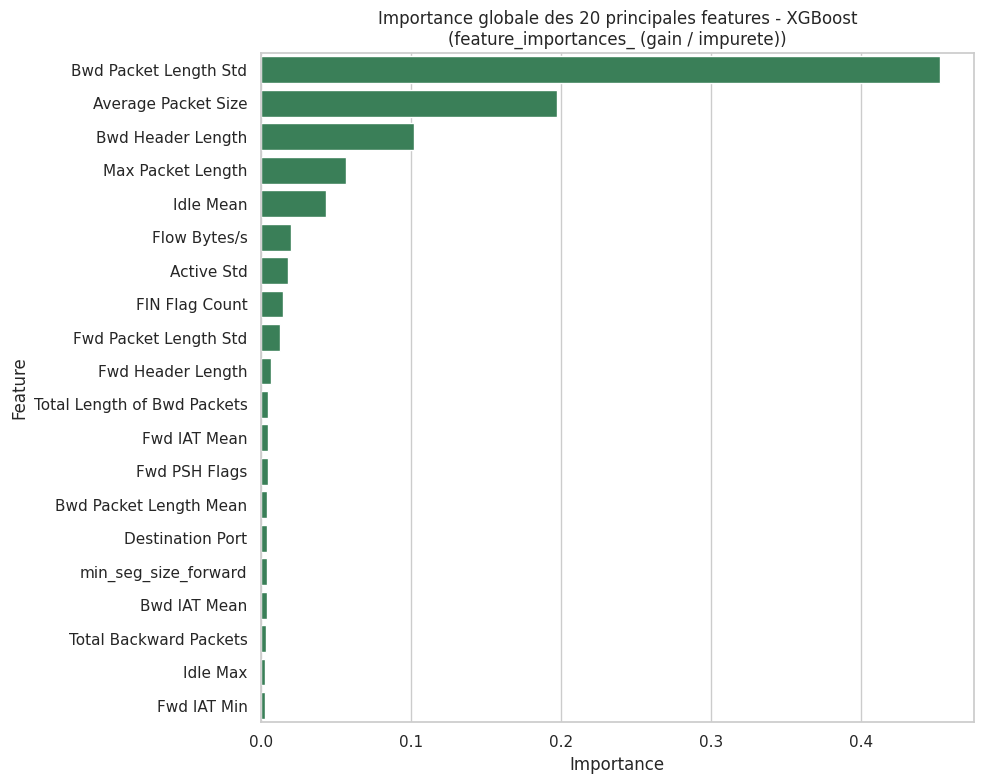

In [9]:
# 7a. Recuperation du modele final dans le pipeline gagnant (derniere etape de named_steps)
if hasattr(best_model, "named_steps"):
    nom_etape_finale = list(best_model.named_steps.keys())[-1]
    modele_final = best_model.named_steps[nom_etape_finale]
else:
    modele_final = best_model
print(f"Modele final dans le pipeline : {type(modele_final).__name__}")

# 7b. Calcul de l'importance selon le type de modele
if hasattr(modele_final, "feature_importances_"):
    methode_importance = "feature_importances_ (gain / impurete)"
    importances = pd.Series(modele_final.feature_importances_, index=features).sort_values(ascending=False)
elif hasattr(modele_final, "coef_"):
    methode_importance = "valeur absolue des coefficients (|coef_|)"
    coefs = np.ravel(modele_final.coef_)
    importances = pd.Series(np.abs(coefs), index=features).sort_values(ascending=False)
else:
    methode_importance = "permutation_importance (echantillon ~5000 lignes)"
    # Echantillon stratifie d'environ 5000 lignes du test pour limiter le cout
    n_perm = 5000
    df_perm = df.groupby("Label_binary", group_keys=False).sample(
        n=min(n_perm // 2, int(y_true.value_counts().min())), random_state=42
    )
    X_perm = df_perm[features]
    y_perm = df_perm["Label_binary"]
    perm = permutation_importance(best_model, X_perm, y_perm, scoring="f1",
                                  n_repeats=5, random_state=42, n_jobs=-1)
    importances = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

print(f"Methode d'explicabilite globale utilisee : {methode_importance}")
top20 = importances.head(20)
print("=== Top 20 des features par importance (modele gagnant) ===")
print(top20.round(4).to_string())

# 7c. Bar chart des 20 features les plus importantes
plt.figure(figsize=(10, 8))
sns.barplot(x=top20.values, y=top20.index, color="seagreen")
plt.title("Importance globale des 20 principales features - " + nom_gagnant + "\n(" + methode_importance + ")")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/09_importance_features.png", dpi=120)
plt.show()

## 8. Explicabilite par alerte : "pourquoi cette alerte"

Pour rendre les alertes exploitables par un analyste, on explique quelques
flux d'attaque CORRECTEMENT detectes par le modele gagnant. Pour chaque flux,
on prend les features les plus importantes du modele et on compare la valeur
du flux a la moyenne du trafic BENIGN (benign_means). Les barres rouges
mettent en evidence les features dont la valeur s'ecarte fortement du normal :
ce sont les raisons de l'alerte.

In [10]:
# 8a. Selection de flux d'attaque bien detectes par le gagnant (un par famille d'attaque)
# Conditions : vraie attaque (Label_binary == 1), bien predit attaque par le gagnant,
# avec un score de risque eleve. On en choisit un par famille pour varier les cas.
df_eval = df.copy()
df_eval["pred_best"] = y_pred_best
df_eval["proba_best"] = proba_best

# Familles d'attaque ciblees (presentes dans le test, volumes suffisants)
familles_cibles = ["DoS", "DDoS", "PortScan"]
indices_alertes = []
for famille in familles_cibles:
    masque = (df_eval["Label_group"] == famille) & (df_eval["Label_binary"] == 1) & (df_eval["pred_best"] == 1)
    candidats = df_eval[masque]
    if len(candidats) > 0:
        # Le flux le plus "confiant" (score de risque le plus eleve) de la famille
        idx = candidats["proba_best"].idxmax()
        indices_alertes.append(idx)

print(f"Nombre de flux d'attaque selectionnes pour l'explicabilite : {len(indices_alertes)}")
for idx in indices_alertes:
    ligne = df_eval.loc[idx]
    print(f"  - index {idx} | famille {ligne['Label_group']:10s} | label {ligne['Label']:20s} | score de risque {ligne['proba_best']:.4f}")

Nombre de flux d'attaque selectionnes pour l'explicabilite : 3
  - index 204199 | famille DoS        | label DoS Hulk             | score de risque 1.0000
  - index 164333 | famille DDoS       | label DDoS                 | score de risque 1.0000
  - index 676938 | famille PortScan   | label PortScan             | score de risque 1.0000


Features utilisees pour l'explication (top 8 par importance) :
['Bwd Packet Length Std', 'Average Packet Size', 'Bwd Header Length', 'Max Packet Length', 'Idle Mean', 'Flow Bytes/s', 'Active Std', 'FIN Flag Count']

=== Pourquoi cette alerte ? Flux index 204199 - DoS Hulk (famille DoS) ===
Score de risque XGBoost : 1.0000
                       Flux (alerte)  Moyenne BENIGN  Ratio flux / BENIGN
Bwd Packet Length Std   3.331638e+03    1.337155e+02              24.9159
Average Packet Size     1.082091e+03    1.312144e+02               8.2467
Bwd Header Length       1.680000e+02   -2.915150e+03              -0.0576
Max Packet Length       7.240000e+03    5.326445e+02              13.5926
Idle Mean               9.840000e+07    4.061898e+06              24.2251
Flow Bytes/s            1.209917e+02    1.666017e+06               0.0001
Active Std              0.000000e+00    5.054974e+04               0.0000
FIN Flag Count          0.000000e+00    1.050000e-02               0.0000

=== Pourq

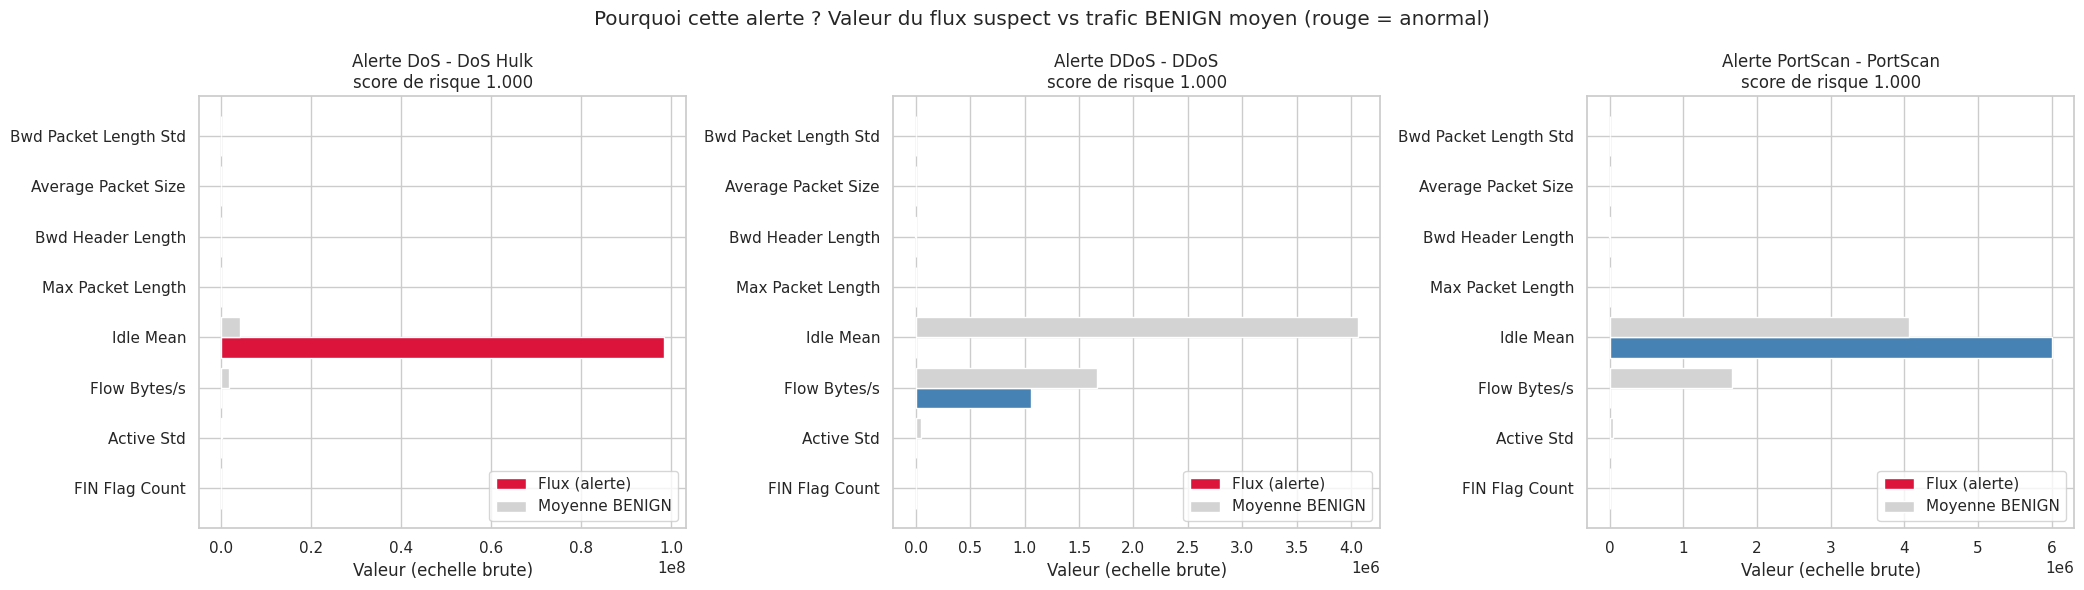

In [11]:
# 8b. Top features par importance retenues pour l'explication
n_top_explic = 8
top_features_explic = importances.head(n_top_explic).index.tolist()
print(f"Features utilisees pour l'explication (top {n_top_explic} par importance) :")
print(top_features_explic)

# 8c. Subplots : un graphique par flux, comparaison valeur du flux vs moyenne BENIGN
nb_alertes = len(indices_alertes)
fig, axs = plt.subplots(1, nb_alertes, figsize=(7 * nb_alertes, 6))
# Si une seule alerte, axs n'est pas un tableau : on l'enveloppe pour la boucle
if nb_alertes == 1:
    axs = [axs]

for i, idx in enumerate(indices_alertes):
    ligne = df_eval.loc[idx]
    # Valeurs du flux et moyennes BENIGN sur les top features
    valeurs_flux = X.loc[idx, top_features_explic].astype(float)
    valeurs_benign = benign_means[top_features_explic].astype(float)

    # Tableau lisible imprime (valeur flux vs normal moyen + ratio)
    tableau = pd.DataFrame({
        "Flux (alerte)": valeurs_flux,
        "Moyenne BENIGN": valeurs_benign,
    })
    tableau["Ratio flux / BENIGN"] = tableau["Flux (alerte)"] / tableau["Moyenne BENIGN"].replace(0, np.nan)
    print(f"\n=== Pourquoi cette alerte ? Flux index {idx} - {ligne['Label']} (famille {ligne['Label_group']}) ===")
    print(f"Score de risque {nom_gagnant} : {ligne['proba_best']:.4f}")
    print(tableau.round(4).to_string())

    # Mise en evidence des features anormales : ecart relatif > 2x la moyenne BENIGN
    ratio = (valeurs_flux / valeurs_benign.replace(0, np.nan)).abs()
    couleurs = ["crimson" if (pd.notna(r) and r > 2.0) else "steelblue" for r in ratio]

    # Barres groupees : flux vs BENIGN par feature
    y_pos = np.arange(len(top_features_explic))
    hauteur = 0.4
    axs[i].barh(y_pos + hauteur / 2, valeurs_flux.values, height=hauteur,
                color=couleurs, label="Flux (alerte)")
    axs[i].barh(y_pos - hauteur / 2, valeurs_benign.values, height=hauteur,
                color="lightgray", label="Moyenne BENIGN")
    axs[i].set_yticks(y_pos)
    axs[i].set_yticklabels(top_features_explic)
    axs[i].invert_yaxis()
    axs[i].set_xlabel("Valeur (echelle brute)")
    axs[i].set_title(f"Alerte {ligne['Label_group']} - {ligne['Label']}\nscore de risque {ligne['proba_best']:.3f}")
    axs[i].legend(loc="lower right")

plt.suptitle("Pourquoi cette alerte ? Valeur du flux suspect vs trafic BENIGN moyen (rouge = anormal)")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/10_explication_alerte.png", dpi=120)
plt.show()

## 9. Sauvegarde de toutes les metriques chiffrees

On serialise dans reports/metrics.json : le classement du bake-off (les 7 F1
CV), le nom du modele selectionne, les metriques de test des trois approches
(precision, recall, f1, accuracy, faux positifs, taux de faux positifs) et les
reductions de faux positifs (gagnant + iso) par rapport a la baseline de regles.

In [12]:
# 9a. Metriques de test par approche (boucle sur le dict de predictions)
metrics = {}
metrics_test = {}
for nom in modeles:
    y_pred = predictions[nom]
    bloc = {
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "fp": fp_par_modele[nom],
        "fp_rate": round(float(fp_rate_par_modele[nom]), 4),
    }
    metrics[nom] = bloc
    metrics_test[nom] = bloc

# 9b. Bloc bake-off : F1 CV moyen/std + selected pour les 7 modeles
metrics["bakeoff"] = {}
for nom, res in cv_results.items():
    metrics["bakeoff"][nom] = {
        "cv_f1_mean": res["cv_f1_mean"],
        "cv_f1_std": res["cv_f1_std"],
        "selected": res["selected"],
    }

# 9c. Modele selectionne, reductions de FP et fourchette de reference
metrics["selected_model"] = nom_gagnant
metrics["fp_reduction_best"] = round(float(fp_reduction_best), 4)
metrics["fp_reduction_iso"] = round(float(fp_reduction_iso), 4)
metrics["target_60_80"] = {
    "cible_min": cible_min,
    "cible_max": cible_max,
    "best_dans_cible": bool(dans_cible_best),
    "iso_dans_cible": bool(dans_cible_iso),
}
# Bloc test regroupe (pratique pour le dashboard de la Phase 5)
metrics["test"] = metrics_test

with open(BASE + "/reports/metrics.json", "w") as fichier:
    json.dump(metrics, fichier, indent=2, ensure_ascii=False)

print("Metriques sauvegardees -> reports/metrics.json")
print(json.dumps(metrics, indent=2, ensure_ascii=False))

Metriques sauvegardees -> reports/metrics.json
{
  "Regles": {
    "precision": 0.4455,
    "recall": 0.6142,
    "f1": 0.5164,
    "accuracy": 0.8057,
    "fp": 97654,
    "fp_rate": 0.1554
  },
  "Isolation Forest": {
    "precision": 0.6199,
    "recall": 0.3994,
    "f1": 0.4858,
    "accuracy": 0.8572,
    "fp": 31274,
    "fp_rate": 0.0498
  },
  "XGBoost": {
    "precision": 0.9966,
    "recall": 0.9987,
    "f1": 0.9976,
    "accuracy": 0.9992,
    "fp": 438,
    "fp_rate": 0.0007
  },
  "bakeoff": {
    "LinearSVC": {
      "cv_f1_mean": 0.8525,
      "cv_f1_std": 0.004,
      "selected": false
    },
    "DecisionTree": {
      "cv_f1_mean": 0.8567,
      "cv_f1_std": 0.0041,
      "selected": false
    },
    "LogisticRegression": {
      "cv_f1_mean": 0.8597,
      "cv_f1_std": 0.0051,
      "selected": false
    },
    "GaussianNB": {
      "cv_f1_mean": 0.377,
      "cv_f1_std": 0.016,
      "selected": false
    },
    "RandomForest": {
      "cv_f1_mean": 0.9947,
      

## 10. Synthese finale

Recapitulatif en clair du bake-off, de la comparaison des trois approches sur
le test et de la reduction des faux positifs.

In [13]:
# 10. Synthese finale imprimee
print("=== Synthese finale - Phase 4 ===")
print(f"Modele gagnant du bake-off : {nom_gagnant} "
      f"(F1 CV {best_model_meta['cv_f1_mean']:.4f} +/- {best_model_meta['cv_f1_std']:.4f})")
print("\nComparaison sur le jeu de test :")
print(df_comparaison.round(4).to_string(index=False))
print(f"\nReduction des faux positifs ({nom_gagnant} vs Regles)    : {fp_reduction_best:.4f} %")
print(f"Reduction des faux positifs (Isolation Forest vs Regles) : {fp_reduction_iso:.4f} %")
print(f"Methode d'explicabilite globale : {methode_importance}")
print("\nFigures generees : 06_cm_regles, 07_cm_isolation_forest, 08_cm_best_model, "
      "09_importance_features, 10_explication_alerte, 11_bakeoff_cv_f1 (reports/figures/).")
print("Metriques chiffrees : reports/metrics.json")

=== Synthese finale - Phase 4 ===
Modele gagnant du bake-off : XGBoost (F1 CV 0.9964 +/- 0.0005)

Comparaison sur le jeu de test :
          Modele  Precision  Recall     F1  Accuracy  Faux positifs  Taux de FP
          Regles     0.4455  0.6142 0.5164    0.8057          97654      0.1554
Isolation Forest     0.6199  0.3994 0.4858    0.8572          31274      0.0498
         XGBoost     0.9966  0.9987 0.9976    0.9992            438      0.0007

Reduction des faux positifs (XGBoost vs Regles)    : 99.5515 %
Reduction des faux positifs (Isolation Forest vs Regles) : 67.9747 %
Methode d'explicabilite globale : feature_importances_ (gain / impurete)

Figures generees : 06_cm_regles, 07_cm_isolation_forest, 08_cm_best_model, 09_importance_features, 10_explication_alerte, 11_bakeoff_cv_f1 (reports/figures/).
Metriques chiffrees : reports/metrics.json
